In [77]:
import gzip
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import beta
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import log_loss, auc, roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
from sklearn.metrics import RocCurveDisplay
from xgboost import XGBClassifier

from bayesbet.base.models import BayesianMLPClassifier
from bayesbet.base.preprocessing import FeatureSelector
from bayesbet.nhl.preprocessing import ShotFeatures
from bayesbet.nhl.visualize import plot_expected_goals

## Data

The foundation of this analysis is the shots data extracted from the NHL play-by-play API in the generate_dataset DVC pipeline. Each play from a game is a shot if it has the type "missed-shot", "shot-on-goal", or "goal". Several other features are extracted from the play, including the details of the last event, the coordinates of the shot, and the number of skaters on the ice.

In [2]:
train_seasons = [
    20142015,
    20152016,
    20162017,
    20172018,
    20182019,
    20192020,
    20202021,
    20212022,
    20222023,
]
test_seasons = [20232024]
train_shots = pd.concat(
    [
        pd.read_parquet(f"../experiments/data/preprocessed/{season}/shots.parquet")
        for season in train_seasons
    ],
    ignore_index=True,
)
test_shots = pd.concat(
    [
        pd.read_parquet(f"../experiments/data/preprocessed/{season}/shots.parquet")
        for season in test_seasons
    ],
    ignore_index=True,
)

In [3]:
train_shots

,shot_is_home_team,home_team_defending_side,zone,shot_type,shot_x,shot_y,goal_x,goal_y,last_event,last_event_x,...,current_score,opposing_score,time_since_even_strength,empty_net,goal,play_number,player_id,venue_name,venue_location,game_id
0,False,right,O,wrist,61,29,89,0,faceoff,1,...,0,0,0,False,False,2,8471976,Air Canada Centre,Toronto,2014020001
1,True,right,O,backhand,54,-29,89,0,blocked-shot,62,...,0,0,0,False,False,4,8475098,Air Canada Centre,Toronto,2014020001
2,True,right,O,wrist,40,-32,89,0,blocked-shot,42,...,0,0,0,False,False,9,8471392,Air Canada Centre,Toronto,2014020001
3,True,right,O,snap,72,8,89,0,shot-on-goal,40,...,0,0,0,False,False,10,8470207,Air Canada Centre,Toronto,2014020001
4,False,right,O,wrist,37,30,89,0,faceoff,-69,...,0,0,0,False,False,17,8476470,Air Canada Centre,Toronto,2014020001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000939,False,right,O,backhand,82,-24,89,0,takeaway,1,...,3,8,0,False,False,358,8479066,T-Mobile Arena,Paradise,2022030415
1000940,False,right,O,slap,42,10,89,0,missed-shot,82,...,3,8,0,False,False,359,8470595,T-Mobile Arena,Paradise,2022030415
1000941,False,right,D,wrist,-32,38,89,0,giveaway,-71,...,3,8,0,False,False,367,8479372,T-Mobile Arena,Paradise,2022030415
1000942,True,right,O,wrist,36,31,89,0,blocked-shot,59,...,8,3,0,False,False,375,8477447,T-Mobile Arena,Paradise,2022030415


## Model

A few different models are tested, all within the framework of the Scikit-Learn API and pipelines. A custom transformer is introduced to add additional features to the data beyond what was extracted from the play-by-play data during the scraping process. Then a subset of the features are selected for the model, split into float and categorical types so that they can be processed appropriately via a Scaler and OneHotEncoder respectively. Finally, these are passed into the classifier model chosen. One such option is the custom BayesianMLPClassifier, which is a wrapper around a JAX/Blackjax implementation of a Multilayer Perceptron.

In [4]:
float_cols = [
    "shot_x",
    "shot_y",
    "shot_distance",
    "shot_angle",
    "last_event_x",
    "last_event_y",
    "last_event_distance",
    "last_event_angle",
    "time_since_last_event",
    "opposing_skaters",
    "current_skaters",
    "opposing_score",
    "current_score",
    "time_since_even_strength",
    "rebound_angle",
]
categorical_cols = ["shot_type", "last_event", "is_rebound"]

X_train = train_shots.drop(columns=["goal"])
y_train = train_shots["goal"]

X_test = test_shots.drop(columns=["goal"])
y_test = test_shots["goal"]

In [5]:
step_size = 1e-2

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", RobustScaler(), float_cols),
        (
            "onehot",
            OneHotEncoder(drop="if_binary", handle_unknown="infrequent_if_exist"),
            categorical_cols,
        ),
    ]
)

classifier = BayesianMLPClassifier(
    hidden_layer_sizes=(15, 15, 15),
    num_warmup=5000,
    num_samples=70000,
    step_size=step_size,
    show_progress=True,
)

# classifier = MLPClassifier(
#     hidden_layer_sizes=(20, 20, 20, 20), max_iter=1000, alpha=1e-4
# )

# classifier = XGBClassifier(
#     n_estimators=1000, learning_rate=0.1, max_depth=1, random_state=42
# )

pipe = Pipeline(
    [
        ("features", ShotFeatures()),
        ("selector", FeatureSelector(float_cols, categorical_cols)),
        ("preprocess", preprocessor),
        ("classifier", classifier),
    ]
)

The model is evaluated on the training data using cross-validation, with the results shown below. The log loss and AUC are generally consistent across the training and testing data of each split, indicating that the model is not overfitting.

In [6]:
scoring = ["neg_log_loss", "roc_auc"]
scores = cross_validate(
    pipe, X_train, y_train, cv=5, scoring=scoring, return_train_score=True
)
scores

100%|██████████| 75000/75000 [00:41<00:00, 1826.81it/s]
/Users/everett/.local/share/virtualenvs/model-WfP3nPDb/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


{'fit_time': array([39.47934484, 39.14650917, 40.79003787, 39.92226934, 42.09874988]),
 'score_time': array([0.27006602, 0.19137383, 0.1880393 , 0.19248676, 0.29086804]),
 'test_neg_log_loss': array([-0.2205463 , -0.22196206, -0.22298056, -0.2248955 , -0.22541864]),
 'train_neg_log_loss': array([-0.2214745 , -0.22177104, -0.22232309, -0.22610853, -0.22214453]),
 'test_roc_auc': array([0.76451065, 0.76054352, 0.75861962, 0.75425211, 0.74369938]),
 'train_roc_auc': array([0.76120118, 0.76121993, 0.76095521, 0.74859191, 0.75760416])}

In [7]:
-np.mean(scores["train_neg_log_loss"])

0.22276433748915334

In [8]:
np.mean(scores["train_roc_auc"])

0.7579144772214308

In [9]:
-np.mean(scores["test_neg_log_loss"])

0.2231606121734302

In [10]:
np.mean(scores["test_roc_auc"])

0.7563250571623762

Following satisfactory performance on the training data, the model is fit on the entire training set and used to make predictions on both the training and testing data.

In [11]:
pipe.fit(X_train, y_train)

100%|██████████| 75000/75000 [00:38<00:00, 1970.24it/s]


Pipeline(steps=[('features', ShotFeatures()),
                ('selector',
                 FeatureSelector(categorical_cols=['shot_type', 'last_event',
                                                   'is_rebound'],
                                 float_cols=['shot_x', 'shot_y',
                                             'shot_distance', 'shot_angle',
                                             'last_event_x', 'last_event_y',
                                             'last_event_distance',
                                             'last_event_angle',
                                             'time_since_last_event',
                                             'opposing_skaters',
                                             'current_skaters',
                                             'opposing_score', 'current_scor...
                                                   'opposing_skaters',
                                                   'current_skaters',
                                                   'opposing_score',
                                                   'current_score',
                                                   'time_since_even_strength',
                                                   'rebound_angle']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='infrequent_if_exist'),
                                                  ['shot_type', 'last_event',
                                                   'is_rebound'])])),
                ('classifier',
                 BayesianMLPClassifier(hidden_layer_sizes=(15, 15, 15),
                                       num_samples=70000, num_warmup=5000,
                                       show_progress=True))])

In [12]:
y_pred_proba = pipe.predict_proba(X_train)
log_loss(y_train, y_pred_proba)

0.22142338674078718

In [13]:
roc_auc_score(y_train, y_pred_proba[:, 1])

0.7621739646767949

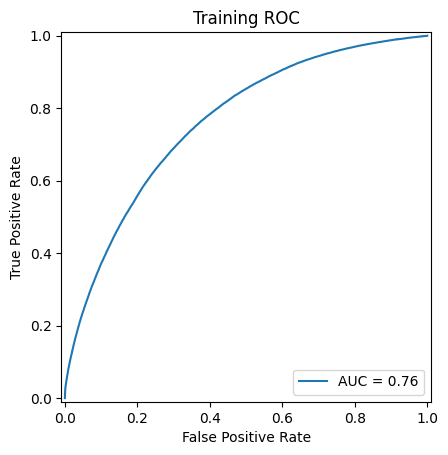

In [14]:
y_pred = pipe.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_pred)
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display.plot()
plt.title("Training ROC")
plt.show()

The same metrics are evaluated agaisnt the testing data, showing a modest increase in the log loss and a decrease in the AUC. Because the test set data represents the most recent full season of data, it is not surprising that the performance is slightly worse than the cross-validation results. The strategies and skills of players are constantly evolving and changing, as is the equipment and technology used in the sport. Some degree of drift is expected, and this is really not a serious amount:

In [15]:
y_pred_proba = pipe.predict_proba(X_test)
log_loss(y_test, y_pred_proba)

0.22815993236161047

In [16]:
roc_auc_score(y_test, y_pred_proba[:, 1])

0.7530818001788948

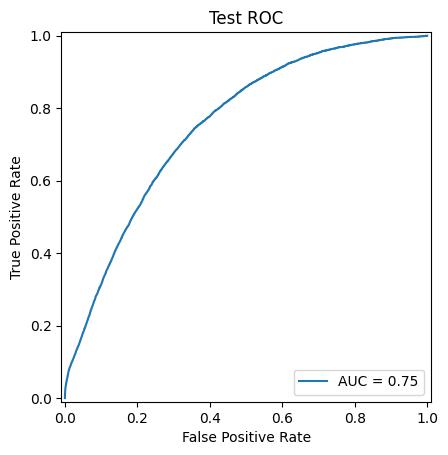

In [17]:
y_pred = pipe.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display.plot()
plt.title("Test ROC")
plt.show()

Text(0.5, 1.0, 'Calibration plot')

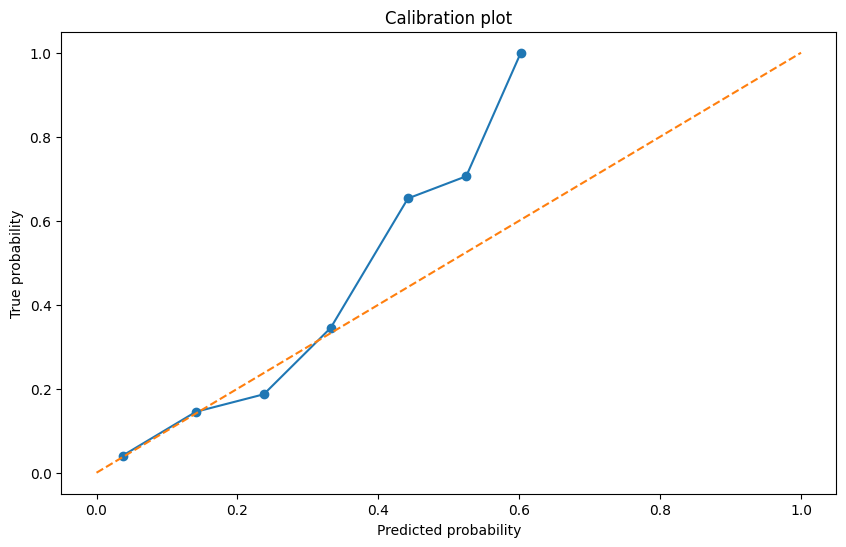

In [80]:
prob_true, prob_pred = calibration_curve(y_test, pipe.predict_proba(X_test)[:, 1], n_bins=10)
plt.figure(figsize=(10, 6))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration plot")

In [55]:
# Get the shot data after the first features transformer has been applied
expected_goals = train_shots.copy()
expected_goals = pipe.named_steps["features"].transform(expected_goals)

expected_goals["expected_goal"] = pipe.predict_proba(
    expected_goals.drop(
        columns=[
            "goal",
            "home_team_defending_side",
            "play_number",
            "player_id",
            "game_id",
        ]
    )
)[:, 1]
expected_goals["expected_goal"] = pipe.predict_proba(expected_goals)[:, 1]

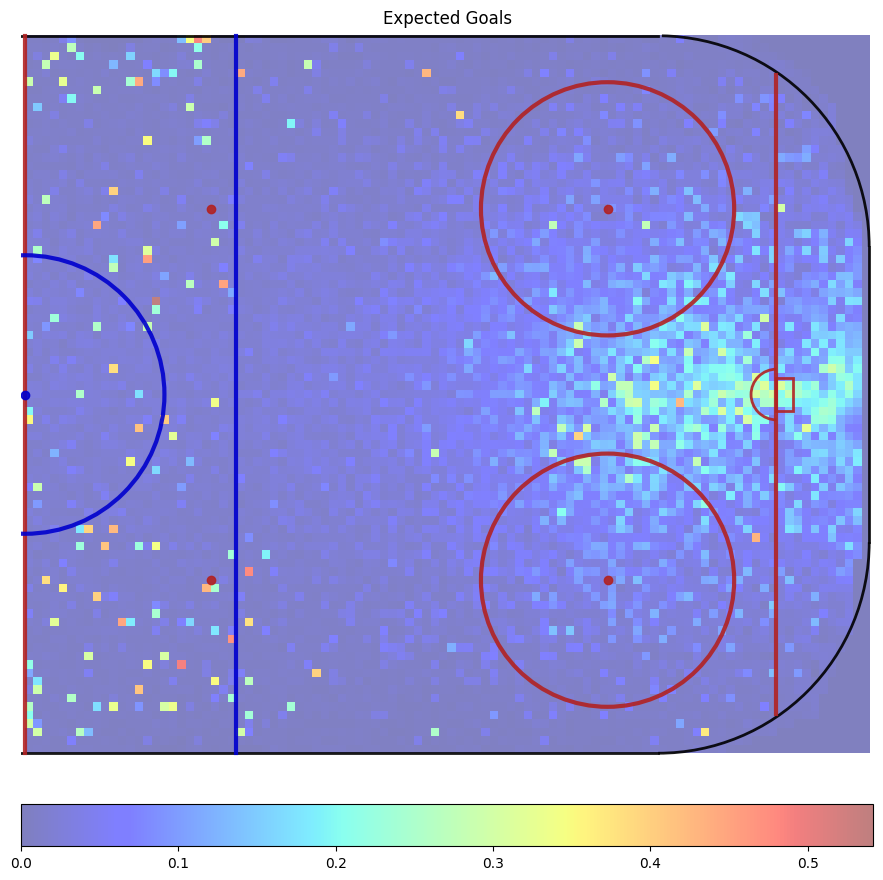

In [56]:
fig = plot_expected_goals(expected_goals)

In [57]:
players_json = {}
seasons = [
    20142015,
    20152016,
    20162017,
    20172018,
    20182019,
    20192020,
    20202021,
    20212022,
    20222023,
    20232024,
]
for season in seasons:
    with gzip.open(f"../experiments/data/raw/{season}/players.json.gz", "rb") as f:
        season_players_json = json.loads(f.read().decode("utf-8"))
        players_json.update(season_players_json)

players_json = {int(key): value for key, value in players_json.items()}

In [58]:
# Get the shot data after the first features transformer has been applied
expected_goals_by_player = expected_goals.copy()
expected_goals_by_player["player_name"] = expected_goals_by_player["player_id"].map(players_json)

In [59]:
best_players = expected_goals_by_player.groupby(["player_id", "player_name"]).agg(
    {"expected_goal": ["mean", "median", "count"]}
)
best_players = best_players[best_players[("expected_goal", "count")] > 500]

In [60]:
best_players.sort_values(("expected_goal", "mean"), ascending=False).head(50)

expected_goal                
                                         mean    median count
player_id player_name                                        
8479977   Kailer Yamamoto            0.111508  0.096141   540
8474038   Paul Byron                 0.109603  0.098701   769
8475786   Zach Hyman                 0.107039  0.094875  1860
8478402   Connor McDavid             0.106772  0.096870  2766
8478462   Nicolas Roy                0.105325  0.091147   594
8478010   Brayden Point              0.104906  0.096195  1979
8471669   Paul Stastny               0.103395  0.096028  1686
8477934   Leon Draisaitl             0.102441  0.094439  2557
8475314   Anders Lee                 0.102408  0.097302  2364
8478047   Michael Bunting            0.101954  0.089687   581
8473533   Jordan Staal               0.101790  0.090807  1801
8476460   Mark Scheifele             0.101631  0.090665  2219
8477404   Jake Guentzel              0.101575  0.090998  1923
8475855   Jesper Fast                0.101267  0.089417  1035
8477497   Sean Monahan               0.101217  0.092122  2075
8470610   Zach Parise                0.101162  0.090814  2186
8476881   Tomas Hertl                0.100243  0.089610  2213
8477989   Christian Dvorak           0.100242  0.089320   947
8475166   John Tavares               0.100003  0.088997  3314
8470794   Joe Pavelski               0.099391  0.091057  2959
8479542   Brandon Hagel              0.099246  0.083262   601
8479314   Matthew Tkachuk            0.098929  0.089480  2203
8478233   Andrew Mangiapane          0.098757  0.084262   945
8475754   Brock Nelson               0.098492  0.086173  2236
8476905   Chandler Stephenson        0.098195  0.086230   782
8470621   Corey Perry                0.098115  0.089050  2183
8474190   Wayne Simmonds             0.097935  0.088017  1766
8480002   Nico Hischier              0.097897  0.088286  1306
8482093   Seth Jarvis                0.097503  0.087290   528
8474641   Adam Henrique              0.097247  0.085797  1688
8477933   Sam Reinhart               0.097139  0.087362  2140
8475913   Mark Stone                 0.097093  0.084147  1995
8475098   Tyler Bozak                0.096554  0.081719  1306
8473546   Michael Grabner            0.096532  0.077025   909
8477500   Bo Horvat                  0.096519  0.085097  2133
8478449   Roope Hintz                0.096150  0.082970  1203
8473604   Jonathan Toews             0.095988  0.078550  1972
8477964   Ivan Barbashev             0.095824  0.081057   806
8475184   Chris Kreider              0.095793  0.089820  2472
8475170   Brayden Schenn             0.095709  0.085009  2127
8476480   Vladislav Namestnikov      0.095470  0.081570  1289
8471698   T.J. Oshie                 0.095469  0.083504  2069
8478427   Sebastian Aho              0.095227  0.078913  2323
8480801   Brady Tkachuk              0.095156  0.085851  1784
8475820   Joonas Donskoi             0.095103  0.080040  1117
8475163   Alex Chiasson              0.095041  0.089616  1056
8478445   Mathew Barzal              0.095041  0.081587  1454
8468208   Joel Ward                  0.095018  0.083236   729
8476918   Jimmy Vesey                0.094998  0.080615  1129
8471675   Sidney Crosby              0.094847  0.080966  2965

In [61]:
def expected_goals_per_game(expected_goals_frequency_per_game, player_posterior_mean):
    return np.sum(expected_goals_frequency_per_game * player_posterior_mean)


def plot_player_expected_goals(player_name, prior_strength=1, num_bins=20):
    selected_player_expected_goals = expected_goals_by_player[
        expected_goals_by_player["player_name"] == player_name
    ]
    X = selected_player_expected_goals["expected_goal"].values.reshape(-1)
    y = selected_player_expected_goals["goal"].values

    # Calculate number of games played and shots taken
    num_games = selected_player_expected_goals["game_id"].nunique()
    total_shots = selected_player_expected_goals.shape[0]

    # Get the maximum expected_goal value rounded up to the nearest 0.1
    max_expected_goal = expected_goals_by_player["expected_goal"].max().round(1)

    bin_edges = np.linspace(0, max_expected_goal, num_bins + 1)
    digitized = np.digitize(X, bin_edges)

    # Calculate bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    alphas = np.zeros(num_bins)
    betas = np.zeros(num_bins)

    for i in range(1, num_bins + 1):
        bin_goals = y[digitized == i]
        bin_expected_goals = X[digitized == i]

        if len(bin_expected_goals) > 0:
            # Set priors based on the bin center
            bin_center = bin_centers[i - 1]
            alpha_prior = prior_strength * bin_center
            beta_prior = prior_strength * (1 - bin_center)

            alphas[i - 1] = alpha_prior + np.sum(bin_goals)
            betas[i - 1] = beta_prior + len(bin_goals) - np.sum(bin_goals)
        else:
            # If the bin is empty, use the bin center as the estimate
            bin_center = bin_centers[i - 1]
            alphas[i - 1] = prior_strength * bin_center
            betas[i - 1] = prior_strength * (1 - bin_center)

    mean_probs = alphas / (alphas + betas)
    ci_lower = beta.ppf(0.025, alphas, betas)
    ci_upper = beta.ppf(0.975, alphas, betas)

    # Create a new figure with 3 subplots
    fig, (ax0, ax1, ax2) = plt.subplots(
        3, 1, figsize=(10, 9), sharex=True, gridspec_kw={"height_ratios": [1, 3, 2]}
    )

    # Plot the distribution of shots
    expected_goal_frequencies, _, _ = ax0.hist(
        X,
        bins=bin_edges,
        density=False,
        weights=np.ones_like(y) / num_games,
        alpha=0.7,
        color="steelblue",
    )
    ax0.set_ylabel("Frequency")
    ax0.set_title("Expected Goals Distribution of Shots Per Game")

    # Plot expected_goal vs actual goals, posterior mean, and bayesian CI
    ax1.scatter(X, y, color="dimgrey", alpha=0.25, label="Observed Shot")
    ax1.axline(
        xy1=(0, 0),
        xy2=(max_expected_goal, max_expected_goal),
        color="grey",
        linestyle="--",
        label="Expected Goal Value of Shot",
    )
    ax1.errorbar(
        bin_centers,
        mean_probs,
        yerr=[mean_probs - ci_lower, ci_upper - mean_probs],
        fmt="o",
        color="steelblue",
        ecolor="steelblue",
        capsize=5,
        label="Player Posterior Mean (95% CI)",
    )
    ax1.set_ylabel("Goal Probability")
    ax1.set_xlabel("Expected Goals")
    ax1.set_title("Player Performance vs Expected Goal Value of Shots")
    ax1.legend()

    # Calculate relative performance
    relative_mean = (mean_probs - bin_centers) / bin_centers * 100
    relative_ci_lower = (ci_lower - bin_centers) / bin_centers * 100
    relative_ci_upper = (ci_upper - bin_centers) / bin_centers * 100

    # Plot relative performance
    ax2.scatter(bin_centers, relative_mean, color="steelblue")
    ax2.errorbar(
        bin_centers,
        relative_mean,
        yerr=[relative_mean - relative_ci_lower, relative_ci_upper - relative_mean],
        fmt="o",
        color="steelblue",
        ecolor="steelblue",
        capsize=5,
    )
    ax2.axhline(y=0, color="grey", linestyle="--")
    ax2.set_ylabel("Relative Performance (%)")
    ax2.set_xlabel("Expected Goals")
    ax2.set_title("Relative Performance to Expected Goal Value")

    plt.suptitle(player_name)
    plt.tight_layout()
    plt.show()

    print(f"Player: {player_name}")
    print(f"Games Played: {num_games}")
    print(f"Total Shots: {total_shots}")
    print(f"Expected Goals per Game: {expected_goals_per_game(expected_goal_frequencies, mean_probs):.4f}")
    print(f"Mean expected_goal: {np.mean(X):.4f}")
    print(f"Median expected_goal: {np.median(X):.4f}")
    print(f"Goal Percentage: {np.mean(y):.4f}")

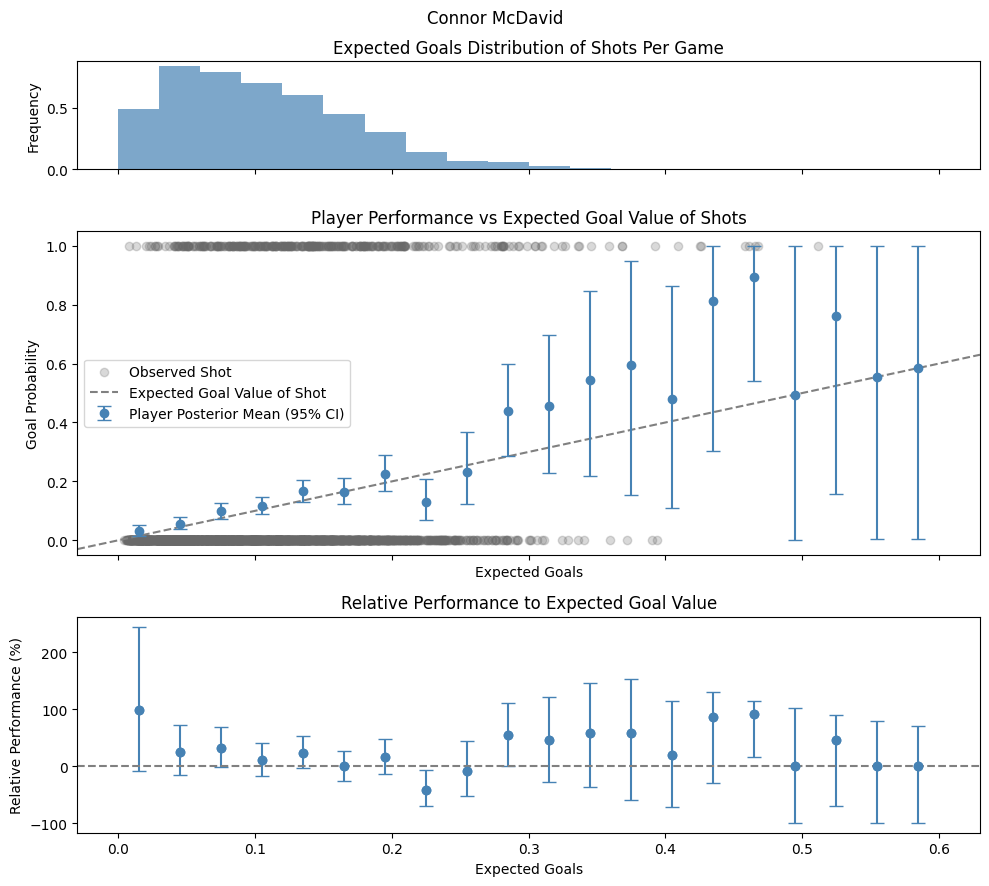

Player: Connor McDavid
Games Played: 613
Total Shots: 2766
Expected Goals per Game: 0.5582
Mean expected_goal: 0.1068
Median expected_goal: 0.0969
Goal Percentage: 0.1244


In [62]:
plot_player_expected_goals("Connor McDavid")

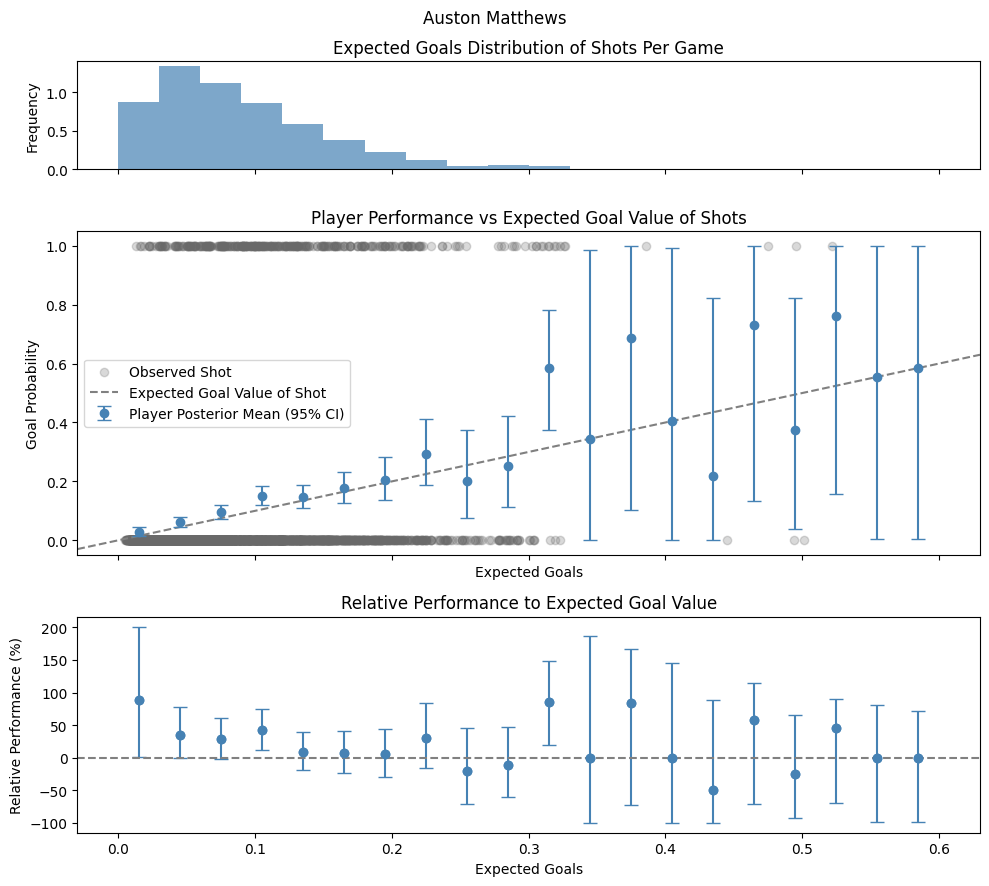

Player: Auston Matthews
Games Played: 530
Total Shots: 2983
Expected Goals per Game: 0.6248
Mean expected_goal: 0.0893
Median expected_goal: 0.0748
Goal Percentage: 0.1113


In [63]:
plot_player_expected_goals("Auston Matthews")

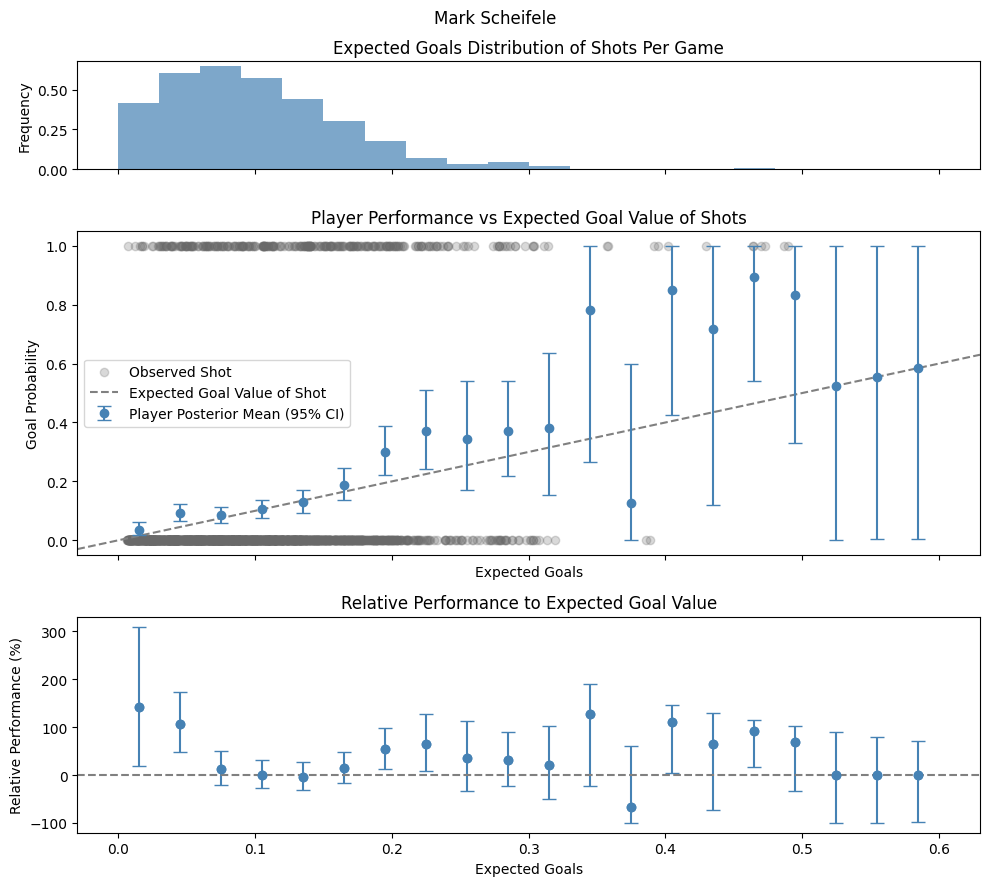

Player: Mark Scheifele
Games Played: 660
Total Shots: 2219
Expected Goals per Game: 0.4344
Mean expected_goal: 0.1016
Median expected_goal: 0.0907
Goal Percentage: 0.1302


In [64]:
plot_player_expected_goals("Mark Scheifele")

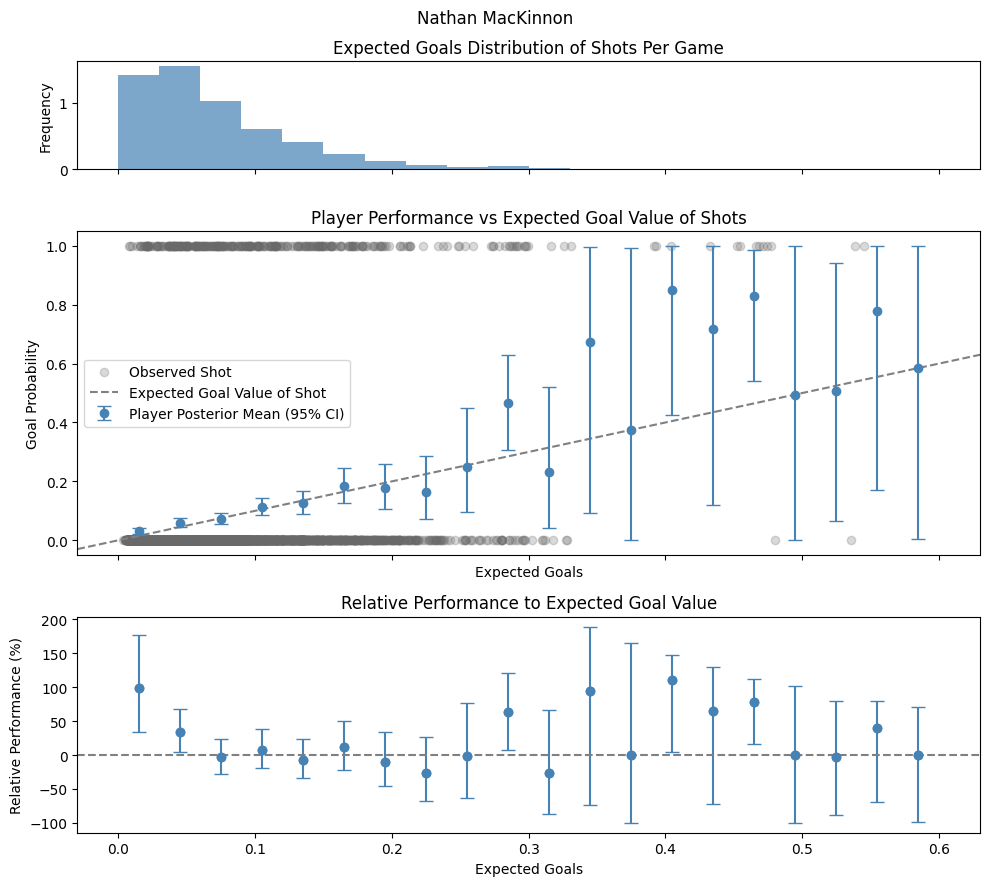

Player: Nathan MacKinnon
Games Played: 686
Total Shots: 3802
Expected Goals per Game: 0.4567
Mean expected_goal: 0.0725
Median expected_goal: 0.0559
Goal Percentage: 0.0829


In [65]:
plot_player_expected_goals("Nathan MacKinnon")

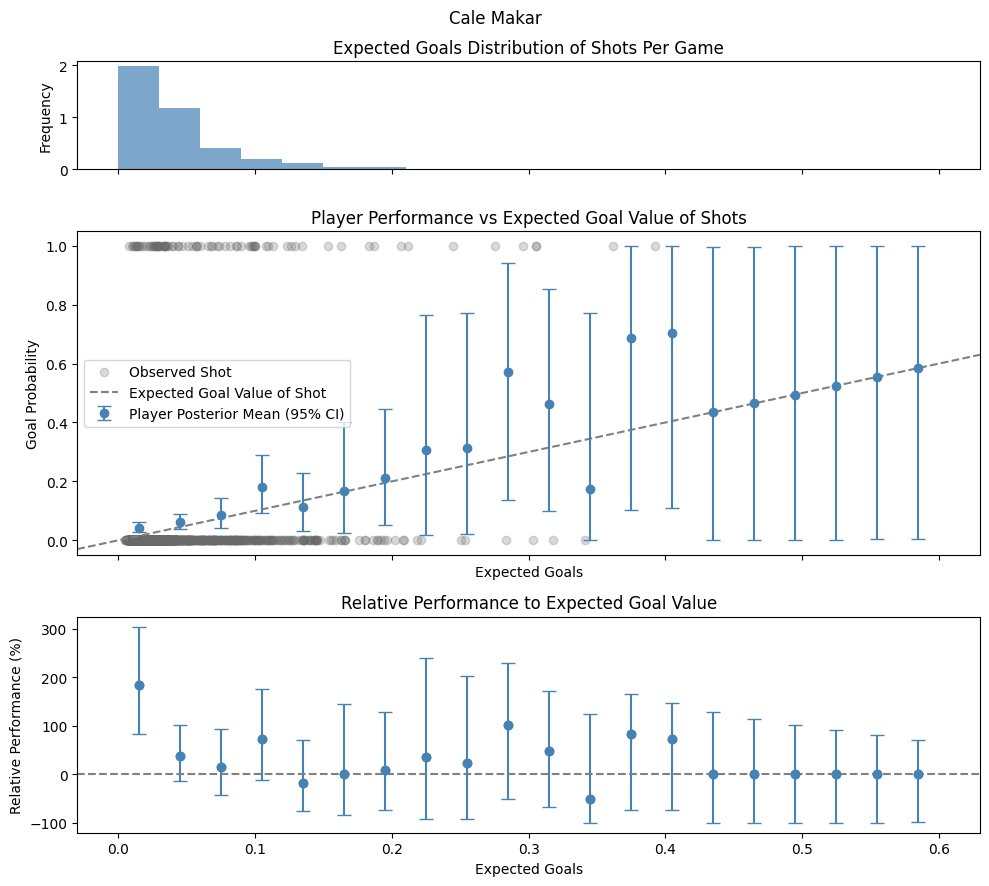

Player: Cale Makar
Games Played: 286
Total Shots: 1149
Expected Goals per Game: 0.2827
Mean expected_goal: 0.0450
Median expected_goal: 0.0306
Goal Percentage: 0.0714


In [66]:
plot_player_expected_goals("Cale Makar")

In [67]:
goal_tended_shots = expected_goals_by_player[expected_goals_by_player["empty_net"] == False].reset_index(
    drop=True
)
goal_tended_shots["goal"] = goal_tended_shots["goal"].astype(int)

In [68]:
empty_net_shots = expected_goals_by_player[expected_goals_by_player["empty_net"] == False].reset_index(
    drop=True
)
empty_net_shots["goal"] = empty_net_shots["goal"].astype(int)

In [69]:
def plot_expected_goals_by_feature(expected_goals, x_axis_feature="shot_distance", hue_feature="opposing_skaters"):
    plt.figure(figsize=(12, 8))

    if len(expected_goals[hue_feature].unique()) > 20:
        legend = None
        color = "viridis"
    else:
        legend = "full"
        color = "tab10"

    sns.scatterplot(
        data=expected_goals,
        x=x_axis_feature,
        y="expected_goal",
        hue=hue_feature,
        palette=color,
        alpha=0.25,
        legend=legend,
    )

    x_axis_feature_title = x_axis_feature.replace("_", " ").title()
    hue_feature_title = hue_feature.replace("_", " ").title()

    plt.title(f"Expected Goal vs {x_axis_feature_title}")
    plt.xlabel(x_axis_feature_title)
    plt.ylabel("Expected Goal Value")
    plt.legend(title=hue_feature_title, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

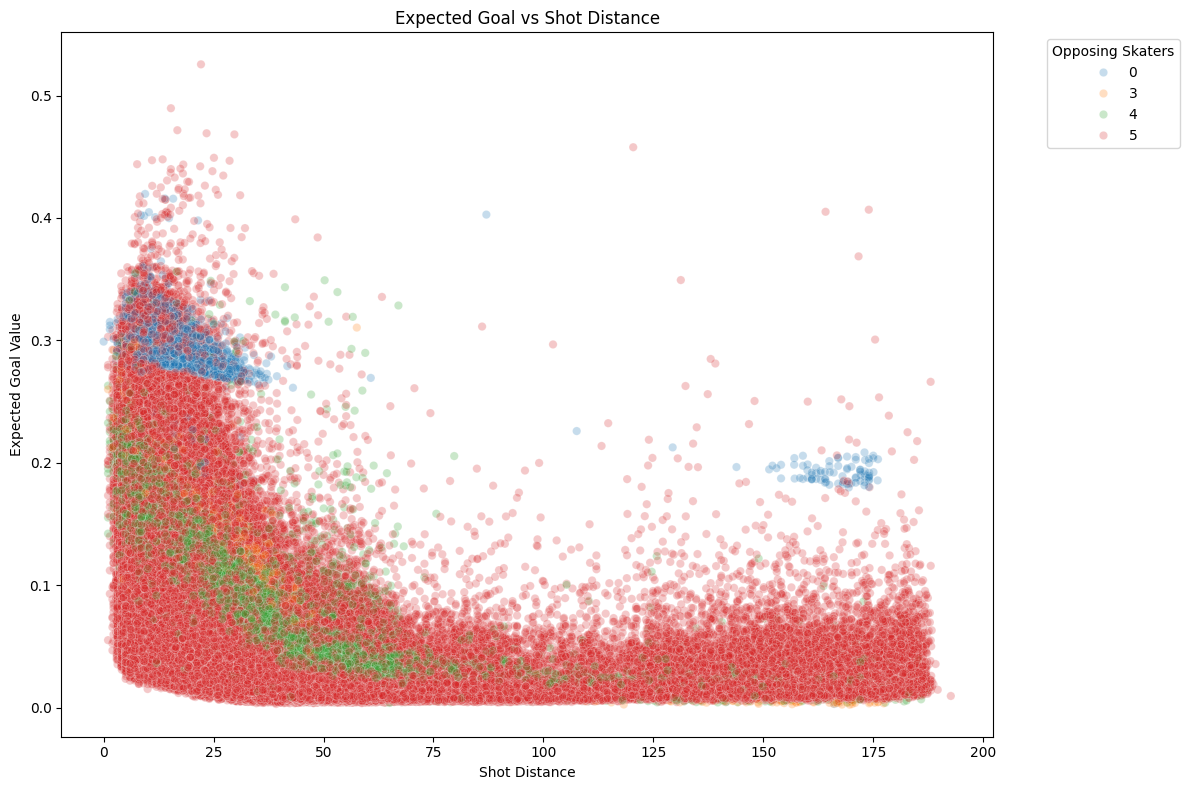

In [70]:
plot_expected_goals_by_feature(goal_tended_shots, x_axis_feature="shot_distance", hue_feature="opposing_skaters")

In [71]:
goal_tended_shots[((goal_tended_shots["opposing_skaters"] == 0) & (goal_tended_shots["shot_distance"] > 100) & (goal_tended_shots["expected_goal"] > 0.2))]

,shot_is_home_team,home_team_defending_side,zone,shot_type,shot_x,shot_y,goal_x,goal_y,last_event,last_event_x,...,venue_location,game_id,shot_distance,shot_angle,last_event_distance,last_event_angle,is_rebound,rebound_angle,expected_goal,player_name
2578,True,left,O,backhand,-68,-4,89,0,period-start,0,...,Vancouver,2014020031,157.050947,-0.025472,68.117545,0.000000,False,-0.000000,0.203829,Nick Bonino
4293,False,right,O,backhand,-76,-1,89,0,missed-shot,-76,...,Uniondale,2014020050,165.003030,-0.006061,5.000000,0.024238,False,-0.000000,0.201352,Brent Burns
20667,False,right,D,backhand,-84,-1,89,0,period-start,0,...,Sunrise,2014020246,173.002890,-0.005780,84.005952,0.000000,False,-0.000000,0.208447,Frans Nielsen
20668,True,right,O,backhand,-86,1,89,0,goal,84,...,Sunrise,2014020246,175.002857,0.005714,170.000000,0.197396,False,-0.000000,0.205791,Jonathan Huberdeau
20669,False,right,O,slap,-86,1,89,0,goal,86,...,Sunrise,2014020246,175.002857,0.005714,172.011628,-0.321751,False,0.000000,0.203771,Kyle Okposo
20671,False,right,O,slap,-84,-7,89,0,shot-on-goal,-85,...,Sunrise,2014020246,173.141561,-0.040440,10.049876,0.017240,True,-0.057680,0.202276,John Tavares
20672,True,right,O,snap,-87,-5,89,0,missed-shot,84,...,Sunrise,2014020246,176.071008,-0.028401,171.420536,0.950547,False,-0.000000,0.202880,Brad Boyes
80308,False,right,O,backhand,-82,2,89,0,missed-shot,80,...,Sunrise,2014020960,171.011696,0.011695,162.443836,-0.837981,False,0.000000,0.204652,Colton Sceviour
222387,False,left,O,wrist,-78,-2,89,0,period-start,0,...,Vancouver,2016020029,167.011976,-0.011975,78.025637,0.000000,False,-0.000000,0.203831,Sam Bennett
243862,True,left,D,wrist,-40,-10,89,0,missed-shot,-72,...,Anaheim,2016020287,129.387016,-0.077365,34.539832,0.018631,False,-0.000000,0.212561,Ondrej Kase


In [72]:
goal_tended_shots[goal_tended_shots["current_skaters"] == 4]

,shot_is_home_team,home_team_defending_side,zone,shot_type,shot_x,shot_y,goal_x,goal_y,last_event,last_event_x,...,venue_location,game_id,shot_distance,shot_angle,last_event_distance,last_event_angle,is_rebound,rebound_angle,expected_goal,player_name
37,True,left,O,wrist,49,-21,89,0,faceoff,-67,...,Toronto,2014020001,45.177428,-0.483447,116.017240,-0.146381,False,-0.0,0.062668,Brandon Kozun
53,False,left,D,snap,-40,21,89,0,blocked-shot,-64,...,Toronto,2014020001,130.698125,0.161375,45.793013,-0.117109,False,0.0,0.065782,Brandon Prust
98,False,left,O,wrist,62,23,89,0,missed-shot,-34,...,Boston,2014020002,35.468296,0.705568,96.420952,0.254520,False,0.0,0.076255,Sean Couturier
116,True,right,O,wrist,56,15,89,0,faceoff,-70,...,Boston,2014020002,36.249138,0.426627,126.253713,0.143658,False,0.0,0.042412,Brad Marchand
150,False,left,D,backhand,-64,-38,89,0,shot-on-goal,-48,...,Boston,2014020002,157.648343,-0.243440,72.780492,0.236373,False,-0.0,0.031631,Braydon Coburn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995047,True,left,N,wrist,-1,6,89,0,blocked-shot,-75,...,Sunrise,2022030413,90.199778,0.066568,74.813100,-0.030478,False,0.0,0.027793,Sam Bennett
995060,False,right,O,wrist,51,30,89,0,giveaway,-63,...,Sunrise,2022030413,48.414874,0.668289,117.153745,0.019734,False,0.0,0.083532,Brett Howden
995068,False,right,O,snap,69,10,89,0,faceoff,-20,...,Sunrise,2022030413,22.360680,0.463648,94.578010,-0.199159,False,0.0,0.094673,Chandler Stephenson
995069,True,right,O,wrist,72,39,89,0,missed-shot,-69,...,Sunrise,2022030413,42.544095,1.159732,149.271565,-0.063207,False,0.0,0.008703,Gustav Forsling


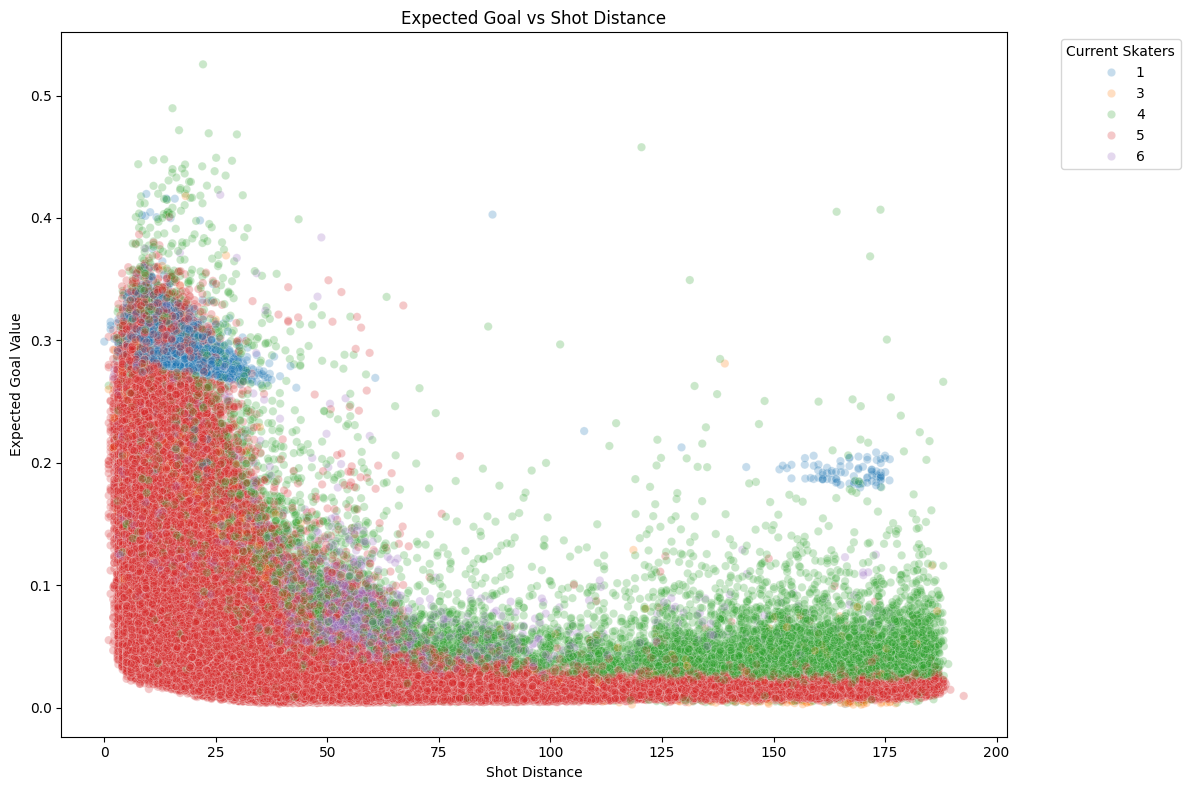

In [73]:
plot_expected_goals_by_feature(goal_tended_shots, x_axis_feature="shot_distance", hue_feature="current_skaters")

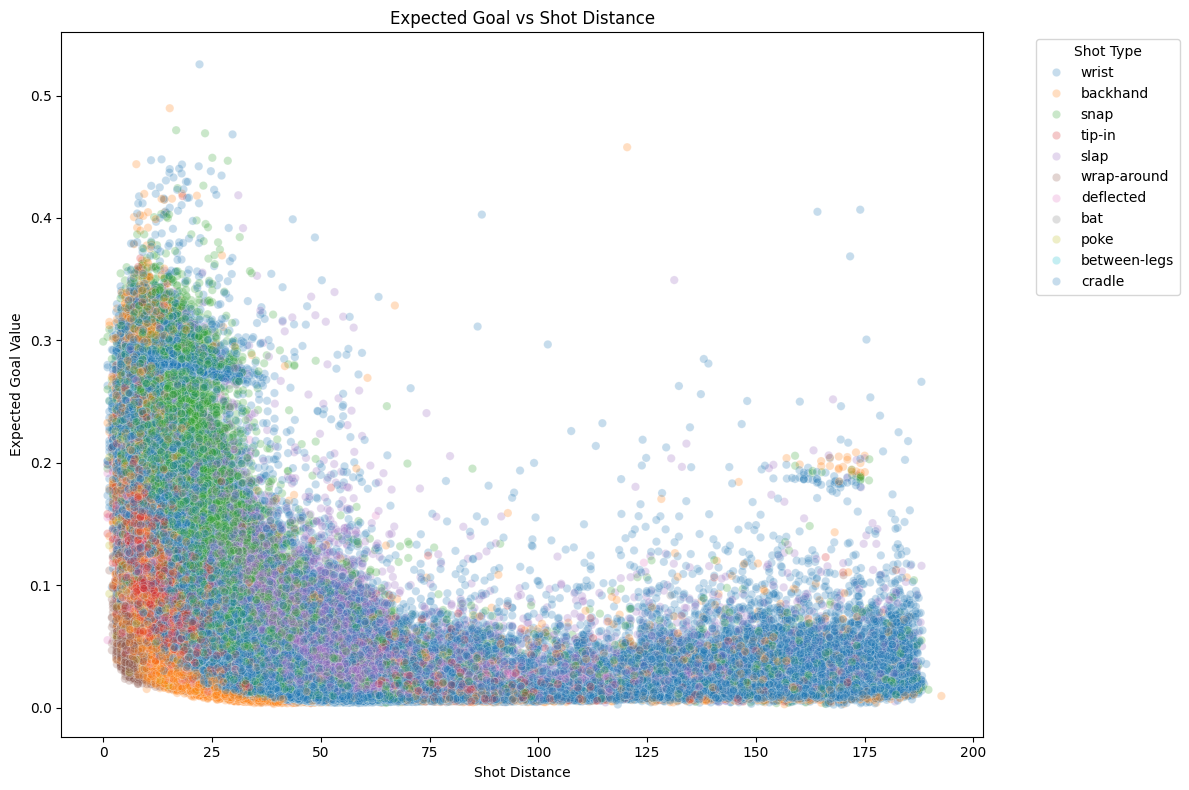

In [74]:
plot_expected_goals_by_feature(empty_net_shots, x_axis_feature="shot_distance", hue_feature="shot_type")

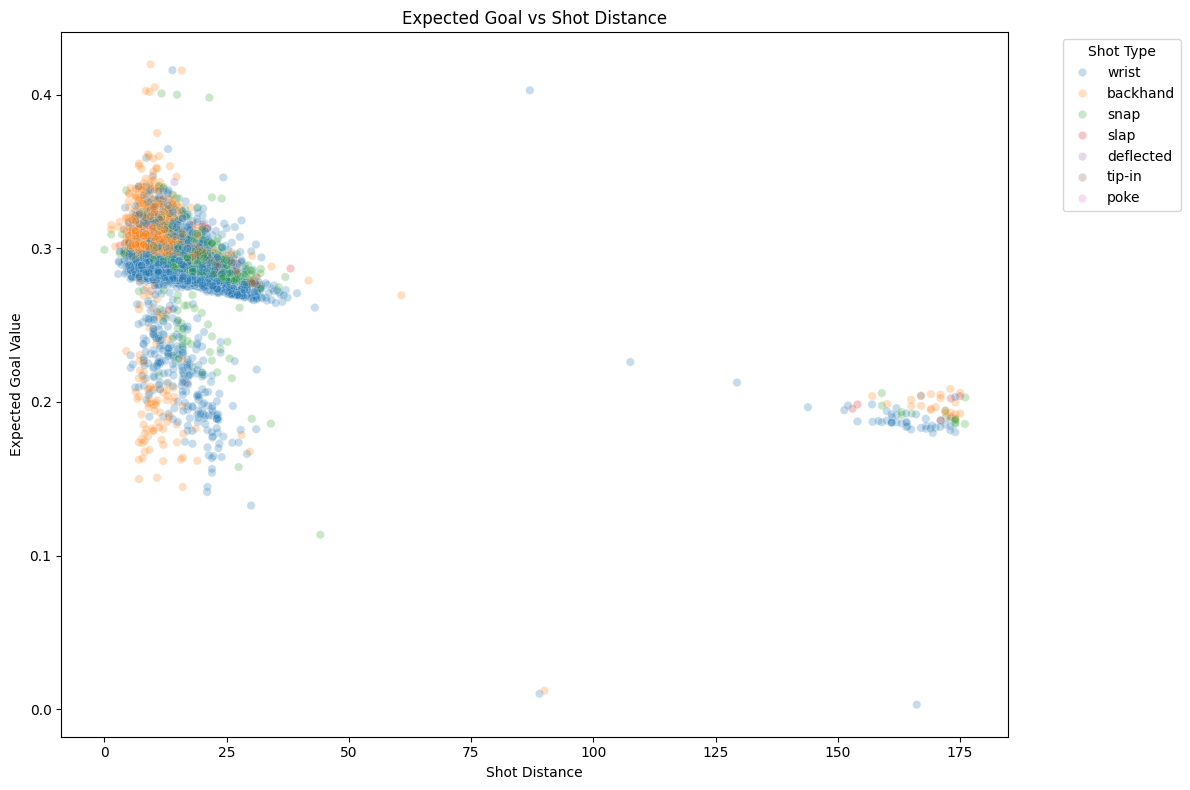

In [75]:
shoot_out_shots = expected_goals_by_player[
    (
        (expected_goals_by_player["current_skaters"] == 1)
        & (expected_goals_by_player["opposing_skaters"] == 0)
    )
].reset_index(drop=True)
plot_expected_goals_by_feature(shoot_out_shots, x_axis_feature="shot_distance", hue_feature="shot_type")